# Cycle Closure Error Analysis

Cycle closure analysis is a useful internal consistency check for relative binding free energy networks. For a closed loop of transformations, the signed sum of the calculated ΔΔG values should be close to zero. A large non-zero value indicates that at least one edge in the cycle is inconsistent with the others and may have convergence or sampling issues.

However, a low cycle closure error can also arise by chance from cancellation of errors, so it does not prove that every edge is well sampled. Cycle closure analysis should therefore be included as part of a larger post-simulation analysis pipeline.

<div class="alert alert-block alert-info">
<b>Note</b> Not all alchemical network generation methods incorporate cycles; see <a href="https://konnektor.openfree.energy/en/latest/guide/network_planner.html#network-generators">konnektor for examples.</a>
</div>


In this tutorial we will:

1. Build a ``FEMap`` with two computational sources using the bundled RBFE example data.
2. Calculate cycle closure errors with ``FEMap.get_cycle_closure_dataframe``.
3. Summarise which edges appear in high-closure-error cycles with ``FEMap.get_cycle_closure_edge_statistics_dataframe``.
4. Plot the cycle closure error distribution with ``cinnabar.plotting.plot_cycle_closure``.

<div class="alert alert-block alert-warning">
<b>Important</b> Cycle closure analysis only considers cycles involving three or more ligands. It does not include "self edges" formed by comparing a forward edge with its backward edge, for example A→B against B→A. Forward/backward consistency should be checked separately before adding data to the map.
</div>

## Setting up the FEMap

For this example, we will use RBFE data generated with [OpenFE](https://docs.openfree.energy/en/latest/), which is bundled with ``cinnabar``'s data directory. The dataset contains one set of simulated relative free energy edges (**Method A**). To demonstrate comparing two computational protocols, we also create a second method (**Method B**) by adding ±0.5 kcal/mol Gaussian noise to the Method A values. You can easily swap this out with your own RBFE outputs.

Cycle closure analysis only needs calculated relative free energy edges, so we do not need to add experimental measurements for this tutorial.

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

from collections import defaultdict
import numpy as np
import pandas as pd
from openff.units import unit

from cinnabar import FEMap, plotting

# Load the computational results bundled with cinnabar
rbfe_results = pd.read_csv("../cinnabar/data/computational_data.csv")

# Fix the random seed so Method B is reproducible
rng = np.random.default_rng(seed=42)

femap = FEMap()

# Method A: the original calculated values
for _, result in rbfe_results.iterrows():
    femap.add_relative_calculation(
        labelA=result["Ligand1"],
        labelB=result["Ligand2"],
        value=result["calc_DDG"] * unit.kilocalorie_per_mole,
        uncertainty=result["calc_dDDG(MBAR)"] * unit.kilocalorie_per_mole,
        source="Method A",
    )

# Method B: same edges, perturbed values to mimic another computational protocol
for _, result in rbfe_results.iterrows():
    femap.add_relative_calculation(
        labelA=result["Ligand1"],
        labelB=result["Ligand2"],
        value=(result["calc_DDG"] + rng.normal(0, 0.5)) * unit.kilocalorie_per_mole,
        uncertainty=result["calc_dDDG(MBAR)"] * unit.kilocalorie_per_mole,
        source="Method B",
    )

print(f"FEMap contains {femap.n_ligands} ligands and {femap.n_edges} calculated edges")
rel_df = femap.get_relative_dataframe()
print("Computational sources:", rel_df.loc[rel_df["computational"], "source"].unique().tolist())

FEMap contains 36 ligands and 116 calculated edges
Computational sources: ['Method A', 'Method B']


## Cycle-level closure errors

``get_cycle_closure_dataframe`` reports one row per detected cycle and source. By default, cycles up to length 5 are considered; this can be changed with ``max_cycle_length``.

The reported columns are:

| Label | Description                                                                                                                                                                                                                                                                                                             |
|-------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|``source``| The computational source label, such as ``Method A`` or ``Method B``.                                                                                                                                                                                                                                                   |
| ``cycle``| The ligand labels in the identified closed loop.                                                                                                                                                                                                                                                                        |
| ``cc (kcal/mol)``| The raw unsigned cycle closure error, calculated as the absolute value of the signed sum of ΔΔG values around the cycle.                                                                                                                                                                                                |
| ``cc_per_edge (kcal/mol)``| ``cc (kcal/mol)`` normalised by ``sqrt(number_of_edges_in_cycle)``. This makes cycles with different lengths easier to compare; see equation 5 of [Baumann et al.](https://pubs.acs.org/doi/10.1021/acs.jctc.3c00282).                                                                                                  |
| ``cc_unc_normalized``| ``cc (kcal/mol)`` normalised by the propagated cycle uncertainty, ``sqrt(sum(edge_uncertainty**2))``. Values much larger than 1 indicate closure errors that are large relative to the reported edge uncertainties. This is similar to ``cc_per_edge`` but does not assume the edges all have comparable uncertainties. |

When a cycle traverses an edge in the opposite direction to the stored calculation, ``cinnabar`` automatically changes the sign of that ΔΔG contribution.

In [2]:
cycle_df = femap.get_cycle_closure_dataframe(max_cycle_length=5)
print(f"Detected {len(cycle_df)} cycles across all sources")
cycle_df.head(10)

Detected 92 cycles across all sources


,source,cycle,cc (kcal/mol),cc_per_edge (kcal/mol),cc_unc_normalized
0,Method A,"(CAT-17g, CAT-13i, CAT-13d, CAT-13b)",2.40,1.200000,9.982684
1,Method A,"(CAT-17g, CAT-13i, CAT-13d, CAT-17d)",1.60,0.800000,7.715885
2,Method A,"(CAT-13n, CAT-13a, CAT-13m, CAT-4m, CAT-13k)",1.26,0.563489,4.650745
3,Method A,"(CAT-4b, CAT-4o, CAT-13j, CAT-4m, CAT-13k)",1.23,0.550073,5.263914
4,Method A,"(CAT-4j, CAT-4o, CAT-4b, CAT-13k, CAT-4m)",1.08,0.482991,5.489949
5,Method A,"(CAT-13a, CAT-17g, CAT-13c, CAT-17i)",1.05,0.525000,4.879764
6,Method A,"(CAT-4b, CAT-4o, CAT-4d, CAT-13k)",1.02,0.510000,4.740342
7,Method A,"(CAT-4b, CAT-4o, CAT-4k, CAT-4m, CAT-13k)",0.88,0.393548,4.243737
8,Method A,"(CAT-4o, CAT-13j, CAT-4m, CAT-4c)",0.85,0.425000,4.123106
9,Method A,"(CAT-17g, CAT-17d, CAT-13d, CAT-13b)",0.80,0.400000,4.093156


The cycles with the largest ``cc_per_edge (kcal/mol)`` are good starting points for follow-up. We can sort by this metric to get the largest errors.

In [3]:
cycle_df.sort_values("cc_per_edge (kcal/mol)", ascending=False).head(10)

,source,cycle,cc (kcal/mol),cc_per_edge (kcal/mol),cc_unc_normalized
0,Method A,"(CAT-17g, CAT-13i, CAT-13d, CAT-13b)",2.400000,1.200000,9.982684
46,Method B,"(CAT-17g, CAT-13c, CAT-17i, CAT-13e)",2.052291,1.026146,9.328598
48,Method B,"(CAT-13n, CAT-13a, CAT-13m, CAT-4i)",1.760979,0.880489,7.183182
49,Method B,"(CAT-17g, CAT-13i, CAT-13d, CAT-13b)",1.717944,0.858972,7.145704
47,Method B,"(CAT-13n, CAT-13a, CAT-13m, CAT-4m, CAT-13k)",1.860400,0.831996,6.866861
1,Method A,"(CAT-17g, CAT-13i, CAT-13d, CAT-17d)",1.600000,0.800000,7.715885
50,Method B,"(CAT-17g, CAT-13i, CAT-13d, CAT-17d)",1.306597,0.653299,6.300973
2,Method A,"(CAT-13n, CAT-13a, CAT-13m, CAT-4m, CAT-13k)",1.260000,0.563489,4.650745
54,Method B,"(CAT-4o, CAT-4c, CAT-4m, CAT-4k)",1.117921,0.558961,6.359631
55,Method B,"(CAT-17g, CAT-13c, CAT-17i, CAT-13g)",1.116094,0.558047,4.425601


## Edge-level cycle closure statistics

``get_cycle_closure_edge_statistics_dataframe`` maps the cycle-level results back onto the edges. It does not claim that a particular edge caused the cycle closure error; instead, it identifies edges that occur in cycles with high closure errors and may deserve closer inspection.

The reported columns are:

| Label | Description |
|-------|-------------|
| ``source``| The computational source label.|
| ``ligandA``/``ligandB``| The ligand labels involved in the edge.|
| ``n_cycles``| The number of detected cycles containing that edge.|
| ``mean_cc_per_edge (kcal/mol)``| The mean ``cc_per_edge (kcal/mol)`` over cycles containing the edge.|
| ``max_cc_per_edge (kcal/mol)``| The largest ``cc_per_edge (kcal/mol)`` over cycles containing the edge.|

Because this is based on cycles, edges that do not participate in any detected cycle are absent from the dataframe.

In [4]:
edge_stats_df = femap.get_cycle_closure_edge_statistics_dataframe(max_cycle_length=5)
edge_stats_df.head(10)

,source,ligandA,ligandB,n_cycles,mean_cc_per_edge (kcal/mol),max_cc_per_edge (kcal/mol)
0,Method A,CAT-13i,CAT-17g,2,1.000000,1.200000
1,Method A,CAT-13d,CAT-13i,2,1.000000,1.200000
2,Method A,CAT-13b,CAT-13d,2,0.800000,1.200000
3,Method A,CAT-13b,CAT-17g,2,0.800000,1.200000
4,Method A,CAT-13d,CAT-17d,2,0.600000,0.800000
5,Method A,CAT-17d,CAT-17g,2,0.600000,0.800000
6,Method A,CAT-13a,CAT-13n,2,0.436745,0.563489
7,Method A,CAT-13a,CAT-13m,2,0.436745,0.563489
8,Method A,CAT-13m,CAT-4m,2,0.424853,0.563489
9,Method A,CAT-13k,CAT-13n,2,0.424853,0.563489


For a single source, sorting by ``max_cc_per_edge (kcal/mol)`` highlights edges that appear in at least one poorly closing cycle. Sorting by ``n_cycles`` can identify edges whose statistics are based on more cycle evidence.

In [5]:
edge_stats_df[edge_stats_df["source"] == "Method A"].sort_values(
    ["max_cc_per_edge (kcal/mol)", "n_cycles"], ascending=[False, False]
).head(10)

,source,ligandA,ligandB,n_cycles,mean_cc_per_edge (kcal/mol),max_cc_per_edge (kcal/mol)
0,Method A,CAT-13i,CAT-17g,2,1.000000,1.200000
1,Method A,CAT-13d,CAT-13i,2,1.000000,1.200000
2,Method A,CAT-13b,CAT-13d,2,0.800000,1.200000
3,Method A,CAT-13b,CAT-17g,2,0.800000,1.200000
4,Method A,CAT-13d,CAT-17d,2,0.600000,0.800000
5,Method A,CAT-17d,CAT-17g,2,0.600000,0.800000
26,Method A,CAT-13k,CAT-4m,17,0.257784,0.563489
6,Method A,CAT-13a,CAT-13n,2,0.436745,0.563489
7,Method A,CAT-13a,CAT-13m,2,0.436745,0.563489
8,Method A,CAT-13m,CAT-4m,2,0.424853,0.563489


### Prioritising Edges With Uncertainty-Normalized Cycle Scores

We can also prioritise edges for follow-up using the uncertainty-normalized metric ``cc_unc_normalized``. This analysis does not prove that an edge caused the observed cycle closure error; it only identifies edges that often occur in high-error cycles. For each edge, we calculate the fraction of containing cycles whose uncertainty-normalized closure error is above a threshold. Here we use a cutoff of 2, meaning the closure error is more than twice the propagated cycle uncertainty


In [6]:
# just do the analysis for Method A
method_a_cycles = cycle_df[cycle_df["source"] == "Method A"]
edge_cycles = defaultdict(list)

for _, row in method_a_cycles.iterrows():
    cycle = list(row["cycle"])
    for i, lig in enumerate(cycle):
        lig_a = lig
        # pick the next ligand in the cycle, wrapping around to the start if necessary
        lig_b = cycle[i + 1] if i < len(cycle) - 1 else cycle[0]
        edge = tuple(sorted((lig_a, lig_b)))
        edge_cycles[edge].append(row["cc_unc_normalized"])


# get the fraction of cycles that have cc_unc_normalized > 2
edge_fractions = []
for edge, cc_uncs in edge_cycles.items():
    cc_uns = np.array(cc_uncs)
    fraction = np.mean(cc_uns > 2)
    edge_fractions.append(
        {
            "ligandA": edge[0],
            "ligandB": edge[1],
            "fraction_cc_unc_gt_2": fraction,
            "n_cycles": len(cc_uns),
            "max_cc_unc_normalized": cc_uns.max()
        }
    )
edge_fractions_df = pd.DataFrame(edge_fractions)
edge_fractions_df.sort_values(["fraction_cc_unc_gt_2", "n_cycles", "max_cc_unc_normalized"], ascending=[False, False, False]).head(10)

,ligandA,ligandB,fraction_cc_unc_gt_2,n_cycles,max_cc_unc_normalized
39,CAT-13d,CAT-13h,1.0,3,3.072659
40,CAT-13h,CAT-17i,1.0,3,3.072659
0,CAT-13i,CAT-17g,1.0,2,9.982684
1,CAT-13d,CAT-13i,1.0,2,9.982684
2,CAT-13b,CAT-13d,1.0,2,9.982684
3,CAT-13b,CAT-17g,1.0,2,9.982684
4,CAT-13d,CAT-17d,1.0,2,7.715885
5,CAT-17d,CAT-17g,1.0,2,7.715885
6,CAT-13a,CAT-13n,1.0,2,4.650745
7,CAT-13a,CAT-13m,1.0,2,4.650745


## Plotting the cycle closure distribution

``plot_cycle_closure`` plots a histogram of ``cc_per_edge (kcal/mol)``. If the ``FEMap`` contains multiple computational sources, all sources are plotted by default. You can pass ``sources=[...]`` to plot a subset.

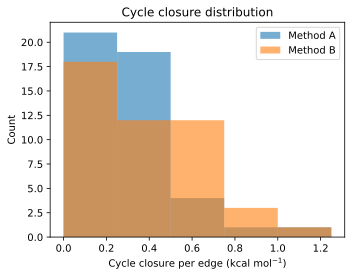

In [7]:
fig = plotting.plot_cycle_closure(
    # the femap containing the edges per source to plot
    femap,
    # the name of the file to save the plot to, or None to show it inline
    filename=None,
    # the maximum cycle length to consider when computing cycle closure statistics
    max_cycle_length=5,
    # the width of the bins in the histogram of cycle closure errors
    bin_width=0.25,
)

You can also focus on a single source. This is useful when a map contains many computational protocols or replicate datasets.

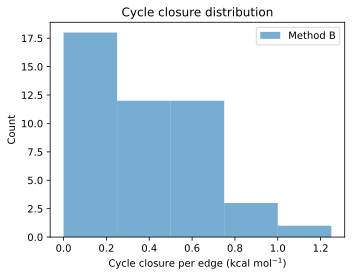

In [8]:
fig = plotting.plot_cycle_closure(
    femap,
    filename=None,
    sources=["Method B"],
    max_cycle_length=5,
    bin_width=0.25,
)

## Recap

- Use ``FEMap.get_cycle_closure_dataframe`` to inspect each detected cycle and its raw, length-scaled, and uncertainty-normalized closure error.
- Use ``FEMap.get_cycle_closure_edge_statistics_dataframe`` to find edges that appear in cycles with high closure errors.
- Use ``plotting.plot_cycle_closure`` to compare the distribution of ``cc_per_edge (kcal/mol)`` across one or more computational sources.
- ``max_cycle_length`` controls the largest cycles included in both dataframe helpers and the plot.
- Forward/backward self edges such as A→B and B→A are not included in this cycle closure analysis and should be checked separately.